# ch245 — Conditional Probability

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. Probability Changes When You Have Information

You roll a die but don't see the result. Someone who can see it tells you: "the number is even." What is now the probability the roll was a 6?

Without the information: P(6) = 1/6.
With the information: the possible outcomes are now {2, 4, 6}, and 6 is one of three equally likely options. P(6 | even) = 1/3.

The information has **restricted** the sample space. Conditional probability formalizes this.

---

## 2. Definition

The **conditional probability** of event A given event B (with P(B) > 0):
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

Interpretation: restrict attention to the outcomes where B occurred (the denominator), and ask what fraction of those also satisfy A (the numerator).

*(P(B) = 0 is excluded because conditioning on an impossible event is undefined.)*

In [1]:
import numpy as np

# Uniform distribution on d6
Omega = set(range(1, 7))

def P(event, omega=Omega):
    return len(event) / len(omega)

def P_given(A, B, omega=Omega):
    """P(A | B) = P(A ∩ B) / P(B)"""
    if len(B) == 0:
        raise ValueError("Cannot condition on impossible event P(B)=0")
    return len(A & B) / len(B)  # equivalent for uniform: |A∩B|/|B|

E_even = {2, 4, 6}
E_six = {6}
E_prime = {2, 3, 5}

print(f"P(6) = {P(E_six):.4f}")
print(f"P(6 | even) = {P_given(E_six, E_even):.4f}")
print(f"P(prime | even) = {P_given(E_prime, E_even):.4f}")
print(f"P(even | prime) = {P_given(E_even, E_prime):.4f}")

P(6) = 0.1667
P(6 | even) = 0.3333
P(prime | even) = 0.3333
P(even | prime) = 0.3333


Notice: P(prime | even) ≠ P(even | prime). Conditional probability is **not symmetric**. This asymmetry is the source of most Bayesian confusion.

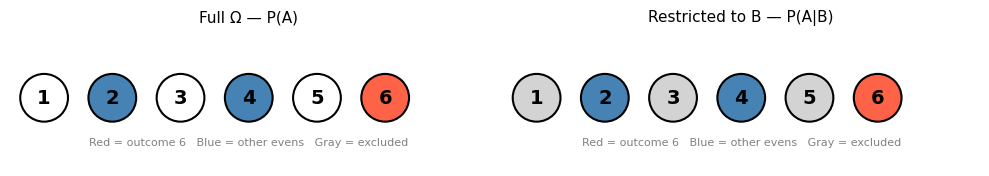

In [2]:
# Geometric view: conditioning restricts the sample space
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, highlight_B, title in zip(
    axes,
    [False, True],
    ["Full Ω — P(A)", "Restricted to B — P(A|B)"]
):
    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

    # Draw all outcomes as circles
    for i, val in enumerate(range(1, 7), start=0):
        is_even = val % 2 == 0
        is_six = val == 6
        
        if highlight_B and not is_even:
            color = 'lightgray'  # outside B — grayed out
        elif is_six:
            color = 'tomato'     # A ∩ B
        elif is_even:
            color = 'steelblue'  # B but not A
        else:
            color = 'white'
        
        circle = plt.Circle((i, 0.5), 0.35, color=color, ec='black', lw=1.5)
        ax.add_patch(circle)
        ax.text(i, 0.5, str(val), ha='center', va='center', fontsize=14, fontweight='bold')

    ax.text(3, -0.2, 'Red = outcome 6   Blue = other evens   Gray = excluded', 
            ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## 3. The Multiplication Rule

Rearranging the definition:
$$P(A \cap B) = P(A \mid B) \cdot P(B)$$

This is the **multiplication rule**. It extends to chains:
$$P(A \cap B \cap C) = P(A \mid B \cap C) \cdot P(B \mid C) \cdot P(C)$$

Use case: drawing cards without replacement.

In [3]:
# Draw two aces from a standard 52-card deck without replacement
# P(1st is ace) = 4/52
# P(2nd is ace | 1st was ace) = 3/51
# P(both aces) = P(1st ace) * P(2nd ace | 1st ace)

p_first_ace = 4 / 52
p_second_ace_given_first = 3 / 51
p_both_aces = p_first_ace * p_second_ace_given_first

print(f"P(first card is ace) = {p_first_ace:.6f}")
print(f"P(second is ace | first was ace) = {p_second_ace_given_first:.6f}")
print(f"P(both aces) = {p_both_aces:.6f}")
print(f"  = 1 in {1/p_both_aces:.1f} deals")

# Simulation
rng = np.random.default_rng(seed=42)
n_trials = 1_000_000
count_both_aces = 0

deck = np.array([0]*4 + [1]*48)  # 0=ace, 1=non-ace
for _ in range(n_trials):
    draw = rng.choice(deck, size=2, replace=False)
    if draw[0] == 0 and draw[1] == 0:
        count_both_aces += 1

print(f"\nSimulation ({n_trials:,} trials): {count_both_aces/n_trials:.6f}")

P(first card is ace) = 0.076923
P(second is ace | first was ace) = 0.058824
P(both aces) = 0.004525
  = 1 in 221.0 deals

Simulation (1,000,000 trials): 0.004465


## 4. Law of Total Probability

If {B₁, B₂, ..., Bₙ} partition Ω:
$$P(A) = \sum_{i=1}^{n} P(A \mid B_i) \cdot P(B_i)$$

This is the **law of total probability**. It allows computing P(A) by conditioning on a partition.

In [4]:
# Factory example: two machines produce parts
# Machine 1 produces 60% of parts, has 2% defect rate
# Machine 2 produces 40% of parts, has 5% defect rate
# What is the overall defect rate?

p_B1 = 0.60  # P(from machine 1)
p_B2 = 0.40  # P(from machine 2)
p_defect_given_B1 = 0.02
p_defect_given_B2 = 0.05

# Law of total probability
p_defect = p_defect_given_B1 * p_B1 + p_defect_given_B2 * p_B2

print("Law of Total Probability: P(defect) = P(defect|B1)P(B1) + P(defect|B2)P(B2)")
print(f"  = {p_defect_given_B1} × {p_B1} + {p_defect_given_B2} × {p_B2}")
print(f"  = {p_defect_given_B1 * p_B1:.4f} + {p_defect_given_B2 * p_B2:.4f}")
print(f"  = {p_defect:.4f}  ({p_defect*100:.2f}% overall defect rate)")

Law of Total Probability: P(defect) = P(defect|B1)P(B1) + P(defect|B2)P(B2)
  = 0.02 × 0.6 + 0.05 × 0.4
  = 0.0120 + 0.0200
  = 0.0320  (3.20% overall defect rate)


## 5. Independence Revisited

A and B are **independent** if and only if:
$$P(A \mid B) = P(A)$$

Knowing B occurred gives no information about A. This is equivalent to the multiplicative definition from ch244: P(A ∩ B) = P(A)·P(B).

In [5]:
# Verify: two dice rolls are independent
from itertools import product

Omega2 = list(product(range(1, 7), range(1, 7)))

def P2_given(A, B):
    """P(A|B) for uniform distribution over Omega2."""
    A, B = set(A), set(B)
    return len(A & B) / len(B)

E_d1_six = {o for o in Omega2 if o[0] == 6}
E_d2_six = {o for o in Omega2 if o[1] == 6}

p_d1_six = len(E_d1_six) / len(Omega2)
p_d1_six_given_d2_six = P2_given(E_d1_six, E_d2_six)

print(f"P(d1=6) = {p_d1_six:.4f}")
print(f"P(d1=6 | d2=6) = {p_d1_six_given_d2_six:.4f}")
print(f"Equal → independent: {abs(p_d1_six - p_d1_six_given_d2_six) < 1e-10}")

P(d1=6) = 0.1667
P(d1=6 | d2=6) = 0.1667
Equal → independent: True


## 6. Summary

- Conditional probability P(A|B) = P(A∩B)/P(B) restricts the universe to outcomes where B occurred.
- P(A|B) ≠ P(B|A) in general — this asymmetry is the root of Bayes' theorem.
- The multiplication rule P(A∩B) = P(A|B)·P(B) chains probabilities through sequences of events.
- The law of total probability decomposes P(A) via a partition.

---

## 7. Forward References

The asymmetry P(A|B) ≠ P(B|A) is precisely what Bayes' theorem relates. Ch246 derives P(B|A) from P(A|B) — this is how you update a prior belief when new evidence arrives. Every probabilistic classifier (naive Bayes, Bayesian neural networks) uses this as its core computation.